# BÀI THỰC HÀNH 5: KIẾN TRÚC TRANSFORMER ENCODER

Họ tên: Trần Nhật Phương Anh  
MSSV: 23520078

<b>Hướng dẫn nộp bài:</b> Các bạn commit và push code lên github, sử dụng file txt đặt tên theo cú pháp <MSSV>.txt chứa đường link dẫn đến github của bài thực hành và nộp file txt này tên courses.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from collections import Counter
import torch.nn.functional as F
import math
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [2]:
# Tải và đọc các file train, test, dev.
PhoNER_train = pd.read_json('PhoNER_COVID19/word/train_word.json', encoding = 'utf-8', lines=True)
PhoNER_dev = pd.read_json('PhoNER_COVID19/word/dev_word.json', encoding = 'utf-8', lines=True)
PhoNER_test = pd.read_json('PhoNER_COVID19/word/test_word.json', encoding = 'utf-8', lines=True)

In [3]:
# In 20 dòng đầu để xem cấu trúc dữ liệu BIO
print('20 dòng đầu trong tập Train PhoNER:')
print(PhoNER_train.head(20))

print('\n20 dòng đầu trong tập Dev PhoNER:')
print(PhoNER_dev.head(20))

print('\n20 dòng đầu trong tập Test PhoNER:')
print(PhoNER_test.head(20))

20 dòng đầu trong tập Train PhoNER:
                                                words  \
0   [Đồng_thời, ,, bệnh_viện, tiếp_tục, thực_hiện,...   
1   [", Số, bệnh_viện, có_thể, tiếp_nhận, bệnh_nhâ...   
2   [Ngoài_ra, ,, những, người, tiếp_xúc, gián_tiế...   
3   [Bà, này, khi, trở, về, quá_cảnh, Doha, (, Qat...   
4   [", Bệnh_nhân, 523, ", và, chồng, là, ", bệnh_...   
5   [Trường_hợp, bệnh_nhân, 188, L.T.H., ,, theo, ...   
6   [Riêng, bệnh_nhân, 91, là, phi_công, người, An...   
7   [Bệnh_nhân, đã, được, xét_nghiệm, có, 3, kết_q...   
8   [Bà, đã, tiếp_xúc, với, người_thân, xác_định, ...   
9   [Chiều, 22, -, 4, ,, bệnh_nhân, được, cho, về,...   
10  [Hôm_qua, ,, hai, bệnh_nhân, Covid, -, 19, cũn...   
11  [8h, ngày, 1, -, 8, ,, bệnh_nhân, 861, chở, co...   
12  [Cả, hai, đều, thuộc, diện, xét_nghiệm, sàng_l...   
13  [Tính, đến, ngày, 11, -, 3, ,, trên, địa_bàn, ...   
14  [Sở, GD, -, ĐT, đã, quán_triệt, tất_cả, thí_si...   
15  [Những, người, vào, trung_tâm, cách_ly, được, ..

In [4]:
# Số câu trong train/dev/test
print('Số câu trong tập Train PhoNER:', len(PhoNER_train))
print('Số câu trong tập Dev PhoNER:', len(PhoNER_dev))
print('Số câu trong tập Test PhoNER:', len(PhoNER_test))

Số câu trong tập Train PhoNER: 5027
Số câu trong tập Dev PhoNER: 2000
Số câu trong tập Test PhoNER: 3000


In [5]:
# Số lượng token mỗi tập
print('Số lượng token trong tập Train PhoNER:', PhoNER_train['words'].apply(len).sum())
print('Số lượng token trong tập Dev PhoNER:', PhoNER_dev['words'].apply(len).sum())
print('Số lượng token trong tập Test PhoNER:', PhoNER_test['words'].apply(len).sum())

Số lượng token trong tập Train PhoNER: 132511
Số lượng token trong tập Dev PhoNER: 56283
Số lượng token trong tập Test PhoNER: 85678


In [6]:
# Thống kê số lần xuất hiện của từng nhãn (B-PER, I-PER, B-LOC, I-LOC, B-ORG, I-ORG, O,...).
train_counts = PhoNER_train['tags'].explode().value_counts().sort_values()
dev_counts = PhoNER_dev['tags'].explode().value_counts().sort_values()
test_counts = PhoNER_test['tags'].explode().value_counts().sort_values()

tong_counts = train_counts.add(dev_counts, fill_value=0).add(test_counts, fill_value=0)

print("Phân phối nhãn trong tập Train PhoNER:\n", train_counts)
print("Phân phối nhãn trong tập Dev PhoNER:\n", dev_counts)
print("Phân phối nhãn trong tập Test PhoNER:\n", test_counts)
print("Tổng cộng các nhãn trong cả ba tập:\n", tong_counts)


Phân phối nhãn trong tập Train PhoNER:
 tags
I-AGE                         2
I-PATIENT_ID                 11
I-NAME                       13
I-JOB                        62
I-TRANSPORTATION             67
B-JOB                       205
B-TRANSPORTATION            226
B-NAME                      349
B-GENDER                    542
B-AGE                       682
B-ORGANIZATION             1137
B-SYMPTOM_AND_DISEASE      1439
I-SYMPTOM_AND_DISEASE      1552
I-DATE                     2500
I-ORGANIZATION             2545
B-DATE                     2549
B-PATIENT_ID               3240
I-LOCATION                 5242
B-LOCATION                 5398
O                        104750
Name: count, dtype: int64
Phân phối nhãn trong tập Dev PhoNER:
 tags
I-NAME                       5
I-PATIENT_ID                 7
I-TRANSPORTATION            25
I-JOB                       49
B-TRANSPORTATION            87
B-JOB                      132
B-NAME                     188
B-GENDER                   27

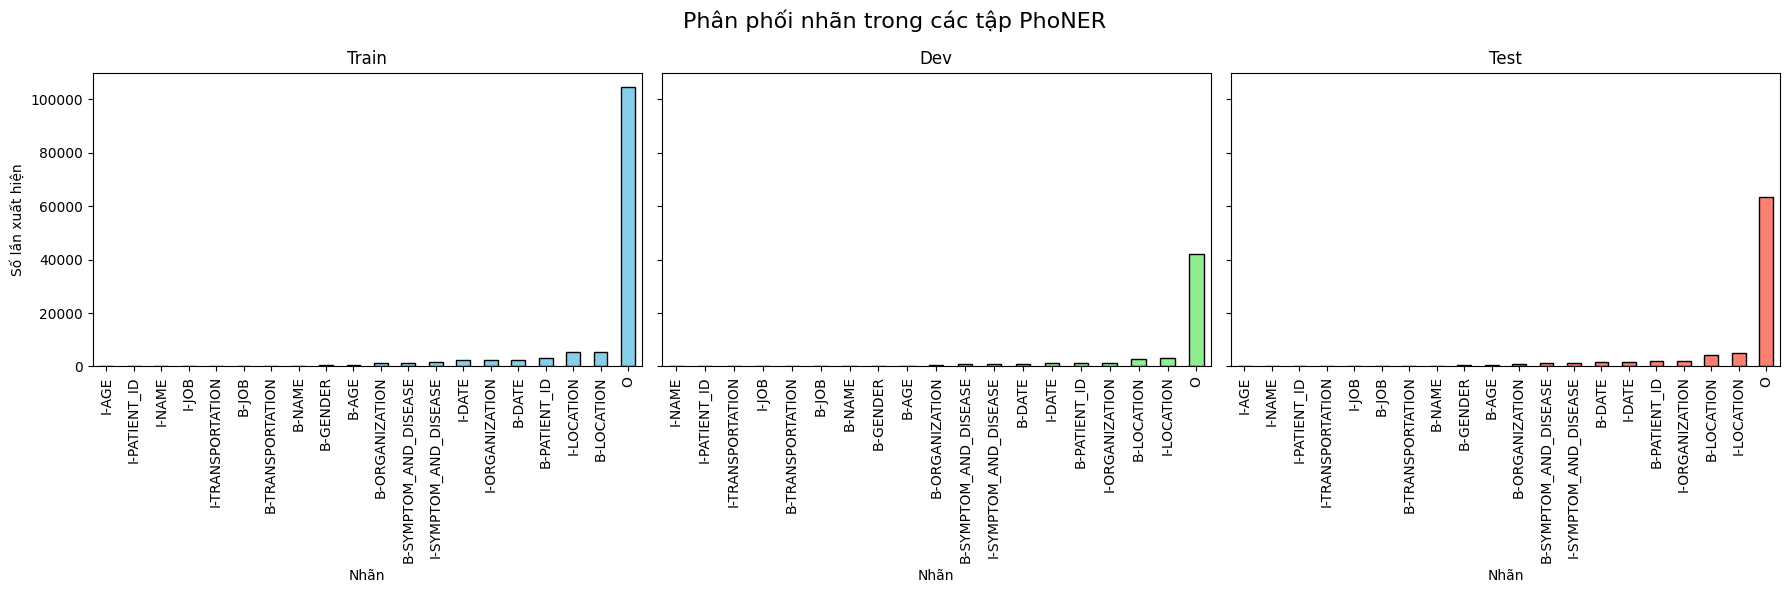

In [7]:
# Vẽ biểu đồ phân phối nhãn cho các tập
fig, axes = plt.subplots(1, 3, figsize=(18,6), sharey=True)

train_counts.plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title("Train")
axes[0].set_xlabel("Nhãn")
axes[0].set_ylabel("Số lần xuất hiện")
axes[0].tick_params(axis='x', rotation=90)

dev_counts.plot(kind='bar', ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_title("Dev")
axes[1].set_xlabel("Nhãn")
axes[1].tick_params(axis='x', rotation=90)

test_counts.plot(kind='bar', ax=axes[2], color='salmon', edgecolor='black')
axes[2].set_title("Test")
axes[2].set_xlabel("Nhãn")
axes[2].tick_params(axis='x', rotation=90)

plt.suptitle("Phân phối nhãn trong các tập PhoNER", fontsize=16)
plt.tight_layout()
plt.show()


- Ở cả ba tập train, dev và test thì nhãn xuất hiện nhiều nhất là O (lần lượt là 104750, 42166, 63546).  
- Ở tập train, nhãn ít nhất là I-AGE với 2.
- Ở tập dev, nhãn ít nhất là I-NAME với 5.  
- Ở tập test, nhãn ít nhất là I-AGE với 6

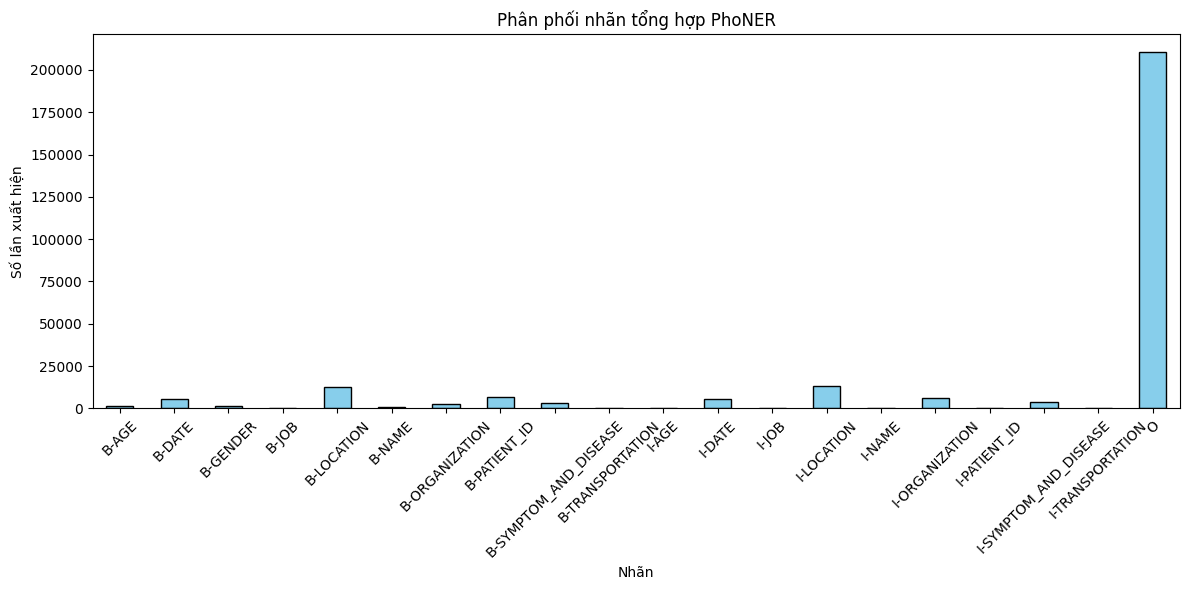

In [8]:
# Vẽ biểu đồ bar chart phân bố nhãn.
plt.figure(figsize=(12,6))
tong_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Phân phối nhãn tổng hợp PhoNER")
plt.xlabel("Nhãn")
plt.ylabel("Số lần xuất hiện")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Ở cả ba tập, nhãn ít nhất là B-AGE với 1625 và nhiều nhất là O với 210462

In [9]:
# Tính số token cho từng câu và tìm min/max/mean
print('Số lượng token trong từng câu của tập Train PhoNER:\n', PhoNER_train['words'].apply(len).describe())
print('Số lượng token trong từng câu của tập Dev PhoNER:\n', PhoNER_dev['words'].apply(len).describe())
print('Số lượng token trong từng câu của tập Test PhoNER:\n', PhoNER_test['words'].apply(len).describe())

Số lượng token trong từng câu của tập Train PhoNER:
 count    5027.000000
mean       26.359857
std        12.504579
min         6.000000
25%        18.000000
50%        24.000000
75%        32.000000
max       161.000000
Name: words, dtype: float64
Số lượng token trong từng câu của tập Dev PhoNER:
 count    2000.000000
mean       28.141500
std        13.466297
min         7.000000
25%        19.000000
50%        25.000000
75%        34.000000
max       138.000000
Name: words, dtype: float64
Số lượng token trong từng câu của tập Test PhoNER:
 count    3000.000000
mean       28.559333
std        13.881500
min         7.000000
25%        19.000000
50%        26.000000
75%        35.000000
max       162.000000
Name: words, dtype: float64


Phần lớn các câu có trung bình khoảng 20 - 35 token nhưng vẫn có một số câu rất dài 138 - 162 token. Điều này tạo độ khó cho LSTM vì mô hình này khó học ngữ cảnh xa và nguy cơ gradient vanishing.

In [10]:
# Tìm Padding tối ưu
def choose_padding_threshold(df, thresholds=[50, 100, 200], name="PhoNERT"):
    # Tính số token cho từng câu
    df['word_count'] = df['words'].apply(len)
    total = len(df)

    # Tỉ lệ câu dưới các ngưỡng
    for threshold in thresholds:
        count = (df['word_count'] <= threshold).sum()
        ratio = count / total * 100
        print(f"Tỉ lệ câu <= {threshold} từ trong {name}: {ratio:.2f}%")
        
choose_padding_threshold(PhoNER_train, name="Train PhoNER")
choose_padding_threshold(PhoNER_dev, name="Dev PhoNER")
choose_padding_threshold(PhoNER_test, name="Test PhoNER")

Tỉ lệ câu <= 50 từ trong Train PhoNER: 95.13%
Tỉ lệ câu <= 100 từ trong Train PhoNER: 99.92%
Tỉ lệ câu <= 200 từ trong Train PhoNER: 100.00%
Tỉ lệ câu <= 50 từ trong Dev PhoNER: 93.50%
Tỉ lệ câu <= 100 từ trong Dev PhoNER: 99.90%
Tỉ lệ câu <= 200 từ trong Dev PhoNER: 100.00%
Tỉ lệ câu <= 50 từ trong Test PhoNER: 92.97%
Tỉ lệ câu <= 100 từ trong Test PhoNER: 99.77%
Tỉ lệ câu <= 200 từ trong Test PhoNER: 100.00%


Chọn padding = 100 vì:  
- Bao phủ gần như 100% cả ba tập dữ liệu.  
- Giữ được khá đủ thông tin mà vẫn bảo đảm hiệu suất mô hình.  
- Tránh lãng phí như chọn 200 và cũng ít cắt bỏ dữ liệu hơn so với 50.  
-> Thế nên đây là lựa chọn cân bằng nhất giữa tốc độ huấn luyện và độ chính xác.

### Bài 2: Xây dựng mô hình Transformer Encoder gồm 3 lớp theo mô tả trong nghiên cứu [Attention is all you need](https://proceedings.neurips.cc/paper_files/paper/2017/file/3f5ee243547dee91fbd053c1c4a845aa-Paper.pdf). Huấn luyện mô hình này cho bài toán gán nhãn chuỗi trên bộ dữ liệu [PhoNERT](https://github.com/VinAIResearch/PhoNER_COVID19).

In [11]:
def build_vocab(datasets):
    word_counter = Counter()
    tag_counter = Counter()
    
    for dataset in datasets:
        for words, tags in zip(dataset['words'], dataset['tags']):
            word_counter.update(words)
            tag_counter.update(tags)
    
    word2idx = {word: idx + 2 for idx, (word, _) in enumerate(word_counter.most_common())}
    word2idx['<PAD>'] = 0
    word2idx['<UNK>'] = 1
    
    tag2idx = {tag: idx for idx, (tag, _) in enumerate(tag_counter.most_common())}
    
    return word2idx, tag2idx

class PhoNERDataset(Dataset):
    def __init__(self, data, word2idx, tag2idx, max_len=100):
        self.data = data
        self.word2idx = word2idx
        self.tag2idx = tag2idx
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        words = self.data.iloc[idx]['words']
        tags = self.data.iloc[idx]['tags']
        
        word_ids = [self.word2idx.get(word, self.word2idx['<UNK>']) for word in words]
        tag_ids = [self.tag2idx[tag] for tag in tags]
        
        if len(word_ids) < self.max_len:
            pad_length = self.max_len - len(word_ids)
            word_ids += [self.word2idx['<PAD>']] * pad_length
            tag_ids += [self.tag2idx['O']] * pad_length  
        else:
            word_ids = word_ids[:self.max_len]
            tag_ids = tag_ids[:self.max_len]
        
        return torch.tensor(word_ids), torch.tensor(tag_ids)
    
word2idx, tag2idx = build_vocab([{"words": PhoNER_train["words"], "tags": PhoNER_train["tags"]}])

train_dataset = PhoNERDataset(PhoNER_train, word2idx, tag2idx, max_len=100)
dev_dataset = PhoNERDataset(PhoNER_dev,   word2idx, tag2idx, max_len=100)
test_dataset = PhoNERDataset(PhoNER_test,  word2idx, tag2idx, max_len=100)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
dev_loader = DataLoader(dev_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [12]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0) 
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return x

In [13]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0, "d_model phải chia hết cho num_heads"
        self.d_head = d_model // num_heads
        self.num_heads = num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        B, T, D = x.shape
        H = self.num_heads
        
        Q = self.W_q(x).view(B, T, H, self.d_head).transpose(1, 2)
        K = self.W_k(x).view(B, T, H, self.d_head).transpose(1, 2)
        V = self.W_v(x).view(B, T, H, self.d_head).transpose(1, 2)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_head)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))
        attn = F.softmax(scores, dim=-1)
        attn = self.dropout(attn)

        context = torch.matmul(attn, V)
        context = context.transpose(1, 2).contiguous().view(B, T, D)

        return self.W_o(context)

In [14]:
class PositionwiseFFN(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.fc2(self.dropout(F.relu(self.fc1(x))))


In [15]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadSelfAttention(d_model, num_heads, dropout)
        self.ffn = PositionwiseFFN(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        x = self.norm1(x + self.dropout(self.self_attn(x, mask)))
        x = self.norm2(x + self.dropout(self.ffn(x)))
        return x

In [16]:
class TransformerEncoder(nn.Module):
    def __init__(self, vocab_size, d_model=512, num_heads=8, d_ff=2048,
                 num_layers=3, max_len=5000, dropout=0.1, pos_enc=None):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_enc = pos_enc
        self.dropout = nn.Dropout(dropout)
        self.layers = nn.ModuleList([EncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])

    def forward(self, x_tokens, pad_mask=None):
        x = self.token_emb(x_tokens)
        if self.pos_enc is not None:
            x = self.pos_enc(x)
        x = self.dropout(x)

        attn_mask = None
        if pad_mask is not None:
            attn_mask = pad_mask.unsqueeze(1).unsqueeze(2)

        for layer in self.layers:
            x = layer(x, attn_mask)
        return x

In [17]:
class NERTagger(nn.Module):
    def __init__(self, vocab_size, num_tags, d_model=512, num_heads=8, d_ff=2048,
                 num_layers=3, max_len=5000, dropout=0.1, pos_enc=None):
        super().__init__()
        self.encoder = TransformerEncoder(
            vocab_size=vocab_size,
            d_model=d_model,
            num_heads=num_heads,
            d_ff=d_ff,
            num_layers=num_layers,
            max_len=max_len,
            dropout=dropout,
            pos_enc=pos_enc
        )

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(d_model, num_tags)
        )

    def forward(self, x_tokens, pad_mask=None):
        enc_out = self.encoder(x_tokens, pad_mask)     
        logits = self.classifier(enc_out)             
        return logits

In [18]:
def sequence_accuracy(logits, targets, ignore_index):
    with torch.no_grad():
        preds = logits.argmax(dim=-1)  
        mask = (targets != ignore_index)
        correct = ((preds == targets) & mask).sum().item()
        total = mask.sum().item()
    return (correct / total) if total > 0 else 0.0


def train_epoch(model, dataloader, optimizer, criterion, device, pad_token_id):
    model.train()
    total_loss, total_acc, batches = 0.0, 0.0, 0

    for x, y in dataloader:
        x, y = x.to(device), y.to(device)
        pad_mask = (x != pad_token_id).long()

        optimizer.zero_grad()
        logits = model(x, pad_mask) 
        loss = criterion(logits.view(-1, logits.size(-1)), y.view(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        acc = sequence_accuracy(logits, y, ignore_index=criterion.ignore_index)
        total_loss += loss.item()
        total_acc += acc
        batches += 1

    return total_loss / batches, total_acc / batches


def eval_epoch(model, dataloader, criterion, device, pad_token_id):
    model.eval()
    total_loss, total_acc, batches = 0.0, 0.0, 0

    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            pad_mask = (x != pad_token_id).long()

            logits = model(x, pad_mask)
            loss = criterion(logits.view(-1, logits.size(-1)), y.view(-1))
            acc = sequence_accuracy(logits, y, ignore_index=criterion.ignore_index)

            total_loss += loss.item()
            total_acc += acc
            batches += 1

    return total_loss / batches, total_acc / batches


def train_model(model, train_loader, dev_loader, optimizer, criterion, device,
                pad_token_id, num_epochs=10, save_path="ner_best.pt"):
    train_losses, train_accs = [], []
    dev_losses, dev_accs = [], []
    best_dev_loss = float("inf")

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device, pad_token_id)
        dev_loss, dev_acc = eval_epoch(model, dev_loader, criterion, device, pad_token_id)

        train_losses.append(train_loss)
        train_accs.append(train_acc)
        dev_losses.append(dev_loss)
        dev_accs.append(dev_acc)

        print(f"Epoch {epoch:02d} | "
              f"Train loss {train_loss:.4f}, acc {train_acc:.4f} | "
              f"Dev loss {dev_loss:.4f}, acc {dev_acc:.4f}")

        if dev_loss < best_dev_loss:
            best_dev_loss = dev_loss
            torch.save({
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "train_losses": train_losses,
                "train_accs": train_accs,
                "dev_losses": dev_losses,
                "dev_accs": dev_accs
            }, save_path)

    return train_losses, train_accs, dev_losses, dev_accs


def test_model(model, test_loader, criterion, device, pad_token_id, checkpoint_path="ner_best.pt"):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state"])

    model.eval()
    total_loss, total_acc, batches = 0.0, 0.0, 0

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            pad_mask = (x != pad_token_id).long()

            logits = model(x, pad_mask)
            loss = criterion(logits.view(-1, logits.size(-1)), y.view(-1))
            acc = sequence_accuracy(logits, y, ignore_index=criterion.ignore_index)

            total_loss += loss.item()
            total_acc += acc
            batches += 1

    print(f"Test | loss {total_loss/batches:.4f}, acc {total_acc/batches:.4f}")
    return total_loss / batches, total_acc / batches

def plot_history(train_losses, train_accs, dev_losses, dev_accs):
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(epochs, train_losses, label="Train Loss")
    plt.plot(epochs, dev_losses, label="Dev Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss theo Epoch")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs, train_accs, label="Train Acc")
    plt.plot(epochs, dev_accs, label="Dev Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy theo Epoch")
    plt.legend()

    plt.show()

Epoch 01 | Train loss 0.8827, acc 0.7244 | Dev loss 0.5454, acc 0.8287
Epoch 02 | Train loss 0.3300, acc 0.8941 | Dev loss 0.4474, acc 0.8602
Epoch 03 | Train loss 0.2057, acc 0.9375 | Dev loss 0.3702, acc 0.8917
Epoch 04 | Train loss 0.1655, acc 0.9495 | Dev loss 0.3495, acc 0.8945
Epoch 05 | Train loss 0.1291, acc 0.9590 | Dev loss 0.4547, acc 0.8844
Epoch 06 | Train loss 0.1160, acc 0.9627 | Dev loss 0.4297, acc 0.8971
Epoch 07 | Train loss 0.0995, acc 0.9691 | Dev loss 0.4629, acc 0.8925
Epoch 08 | Train loss 0.0888, acc 0.9727 | Dev loss 0.4187, acc 0.8992
Epoch 09 | Train loss 0.0814, acc 0.9755 | Dev loss 0.4716, acc 0.8959
Epoch 10 | Train loss 0.0766, acc 0.9762 | Dev loss 0.4658, acc 0.8944


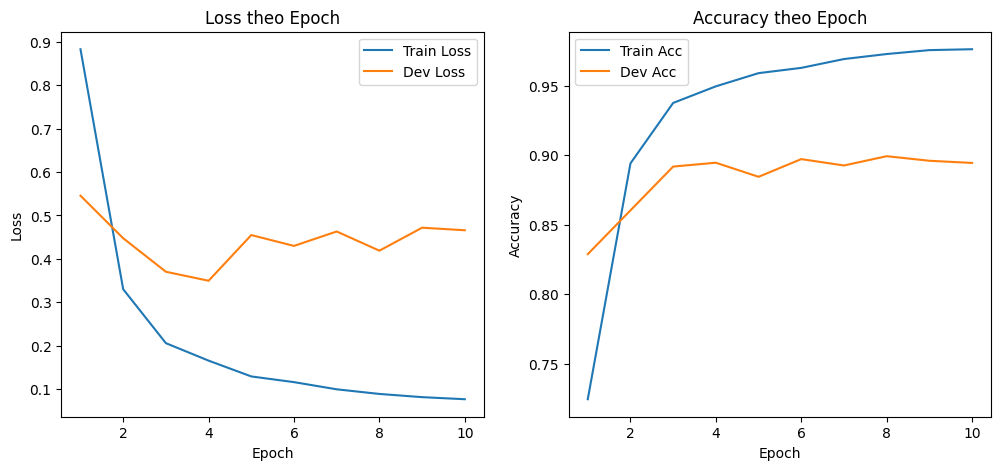

Test | loss 0.4008, acc 0.8828


In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = NERTagger(vocab_size=len(word2idx), num_tags=len(tag2idx), pos_enc=PositionalEncoding(512)).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=tag2idx.get("<PAD>", 0))
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4)

train_losses, train_accs, dev_losses, dev_accs = train_model(
    model, train_loader, dev_loader, optimizer, criterion, device,
    pad_token_id=word2idx["<PAD>"], num_epochs=10, save_path="ner_best.pt"
)

plot_history(train_losses, train_accs, dev_losses, dev_accs)

test_loss, test_acc = test_model(model, test_loader, criterion, device, pad_token_id=word2idx["<PAD>"])

Loss theo Epoch
- Train Loss giảm đều từ khoảng 0.9 xuống gần 0.1, cho thấy mô hình học tốt trên tập huấn luyện.
- Dev Loss giảm ban đầu nhưng bắt đầu dao động nhẹ từ epoch 4 trở đi, biểu hiện khả năng overfitting.

Accuracy theo Epoch
- Train Accuracy tăng liên tục từ khoảng 0.7 lên gần 1.0, đạt mức gần như tuyệt đối trên tập huấn luyện.
- Dev Accuracy tăng nhanh ở giai đoạn đầu nhưng chững lại và dao động sau epoch 4, cho thấy khả năng tổng quát hóa không cải thiện đáng kể.

Tổng kết
- Mô hình đạt hiệu suất cao trên tập huấn luyện nhưng có dấu hiệu overfitting sau epoch 4.


Kết quả trên tập Test
- Loss: 0.4008  
- Accuracy: 0.8828  

Nhận xét
- Mức loss trên tập test ở mức trung bình, cho thấy mô hình vẫn còn sai số nhất định.  
- Accuracy đạt 88.28%, phản ánh mô hình có khả năng dự đoán khá tốt trên dữ liệu chưa từng thấy.  
- So với xu hướng overfitting quan sát ở tập Dev, kết quả này cho thấy mô hình vẫn giữ được khả năng tổng quát hóa tương đối ổn định.  

In [21]:
def plot_confusion_matrix(model, dataloader, device, tag2idx, pad_token_id, pad_tag_id):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            y = y.to(device)
            pad_mask = (x != pad_token_id).long()

            logits = model(x, pad_mask) 
            preds = logits.argmax(dim=-1)  

            for pred_seq, label_seq in zip(preds, y):
                for p, l in zip(pred_seq.cpu().numpy(), label_seq.cpu().numpy()):
                    if l != pad_tag_id:  
                        all_preds.append(p)
                        all_labels.append(l)

    cm = confusion_matrix(all_labels, all_preds, labels=list(tag2idx.values()))
    
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=list(tag2idx.keys()),
                yticklabels=list(tag2idx.keys()))
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix NER")
    plt.show()

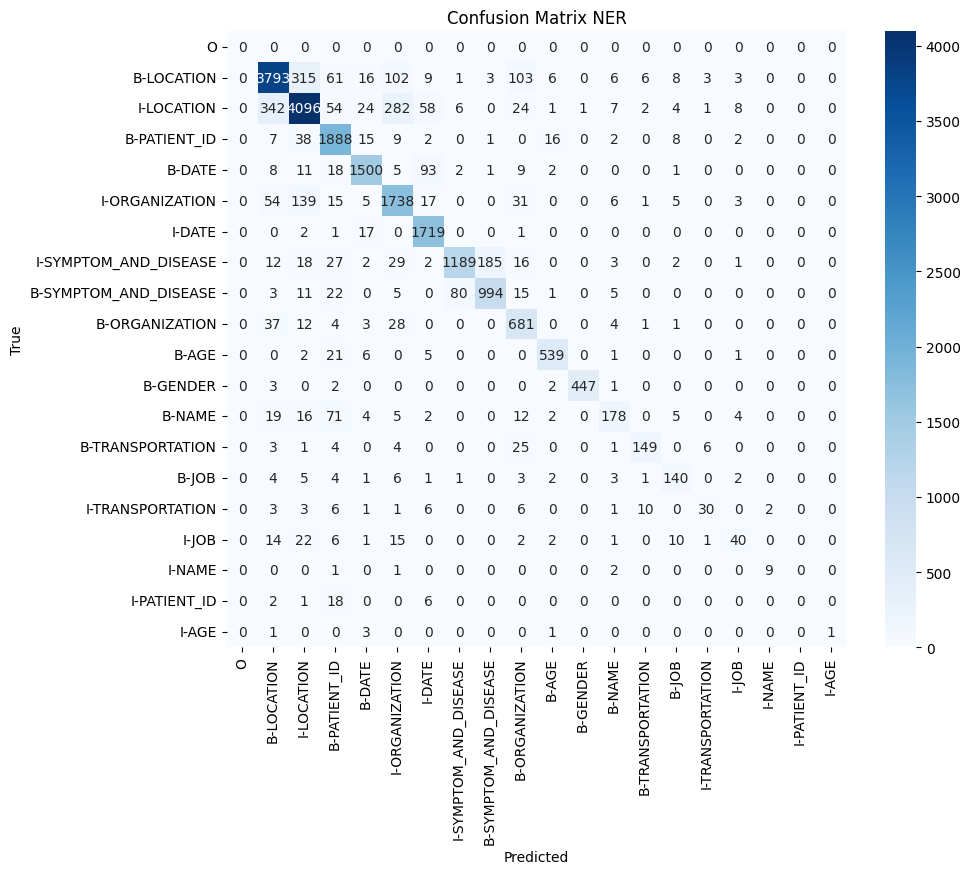

In [23]:
checkpoint = torch.load("ner_best.pt", map_location=device)
model.load_state_dict(checkpoint["model_state"])

plot_confusion_matrix(model, test_loader, device, tag2idx,
                      pad_token_id=word2idx["<PAD>"],
                      pad_tag_id=tag2idx.get("<PAD>", tag2idx.get("O", 0)))

Tổng quan
- Ma trận cho thấy mô hình NER hoạt động tốt với các nhãn phổ biến như B-LOCATION, I-LOCATION, B-PATIENT_ID, B-DATE, I-ORGANIZATION, I-DATE, với số lượng dự đoán đúng cao (trên 1000 mẫu).
- Các nhãn ít phổ biến hơn như B-NAME, B-JOB, B-TRANSPORTATION có số lượng dự đoán đúng thấp hơn (dưới 200 mẫu), phản ánh sự mất cân bằng dữ liệu hoặc độ khó trong nhận diện.

Nhận xét
- I-LOCATION: 4096 dự đoán đúng, là nhãn có độ chính xác cao nhất.
- B-LOCATION: 3793 dự đoán đúng, cũng rất ổn định.
- B-PATIENT_ID: 1888 dự đoán đúng, mô hình nhận diện tốt thông tin định danh.
- I-DATE và B-DATE: lần lượt 1719 và 1500 dự đoán đúng, cho thấy khả năng nhận diện thời gian khá tốt.
- Các nhãn tổ chức (B-ORGANIZATION, I-ORGANIZATION) và triệu chứng (B-SYMPTOM_AND_DISEASE, I-SYMPTOM_AND_DISEASE) cũng được nhận diện tương đối chính xác.
- Các nhãn như B-NAME, B-JOB, B-TRANSPORTATION có độ chính xác thấp hơn, cần cải thiện qua tăng cường dữ liệu hoặc điều chỉnh mô hình.
